<a href="https://colab.research.google.com/github/Aramish44/E-commerce-Data-Analysis/blob/main/Devixo_Task01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART 1


In [ ]:
import pandas as pd

df= pd.read_csv('E-commerce.csv')
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [ ]:

df.tail()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
34495,O134495,C13553,P231412,Fashion,10.44,0.20,1,Debit Card,2025-08-13,3,North,No,8.35,3.04,-0.12,23,Female
34496,O134496,C11349,P218266,Beauty,4.79,0.10,5,Debit Card,2023-12-04,6,South,Yes,21.56,3.37,6.33,61,Female
34497,O134497,C12986,P204345,Electronics,323.64,0.00,5,Credit Card,2025-02-01,6,East,No,1618.20,12.18,182.00,41,Female
34498,O134498,C17196,P217644,Home,23.09,0.05,1,Credit Card,2024-03-27,6,East,No,21.94,5.61,0.53,27,Female
34499,O134499,C13330,P207047,Home,76.84,0.00,1,Debit Card,2025-09-11,6,East,No,76.84,7.57,13.95,19,Male


In [ ]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 34500 rows, 17 columns


In [ ]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(numerical_cols)
print(categorical_cols)

['price', 'discount', 'quantity', 'delivery_time_days', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age']
['order_id', 'customer_id', 'product_id', 'category', 'payment_method', 'order_date', 'region', 'returned', 'customer_gender']


In [ ]:
df.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [ ]:
df.describe(include=['object', 'bool']).T

,count,unique,top,freq
order_id,34500,34500,O134499,1
customer_id,34500,7903,C16704,13
product_id,34500,24912,P200645,7
category,34500,7,Fashion,6254
payment_method,34500,6,Credit Card,12170
order_date,34500,731,2024-12-04,70
region,34500,5,South,7584
returned,34500,2,No,32597
customer_gender,34500,3,Female,16818


PART 2

In [ ]:
import pandas as pd
import numpy as np

df.isnull().sum()

,0
order_id,0
customer_id,0
product_id,0
category,0
price,0
discount,0
quantity,0
payment_method,0
order_date,0
delivery_time_days,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [ ]:
cat_cols = ['category', 'payment_method', 'region']
for col in cat_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.strip().str.title()

In [ ]:
if 'price' in df.columns:
    df = df[df['price'] > 0]
if 'quantity' in df.columns:
    df = df[df['quantity'] > 0]
if 'discount' in df.columns:
    df = df[(df['discount'] >= 0) & (df['discount'] <= 100)]

PART 3

In [ ]:
if 'total_sales' not in df.columns:
    df['total_sales'] = df['price'] * df['quantity'] * (1 - (df['discount'] / 100))

In [ ]:
num_features = ['price', 'quantity', 'discount', 'delivery_time_days', 'total_sales']
num_summary = []

for col in num_features:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

        num_summary.append({
            'Feature': col,
            'Min': round(df[col].min(), 2),
            'Max': round(df[col].max(), 2),
            'Mean': round(df[col].mean(), 2),
            'Median': round(df[col].median(), 2),
            'Std Dev': round(df[col].std(), 2),
            'Skewness': round(df[col].skew(), 2),
            'Outliers Count': outliers_count,
            'Outlier %': round((outliers_count / len(df)) * 100, 2)
        })

num_df = pd.DataFrame(num_summary)
display(num_df)

,Feature,Min,Max,Mean,Median,Std Dev,Skewness,Outliers Count,Outlier %
0,price,1.01,2930.47,119.39,45.66,195.62,3.70,3632,10.53
1,quantity,1.00,5.00,1.49,1.00,0.93,2.05,2070,6.00
2,discount,0.00,0.30,0.05,0.00,0.07,1.54,704,2.04
3,delivery_time_days,3.00,13.00,4.81,5.00,1.24,0.56,27,0.08
4,total_sales,1.01,12931.80,178.86,59.73,374.65,7.89,3770,10.93


/tmp/ipykernel_2027/3748874055.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='total_sales', ax=axes[1, 1], palette='Set2')


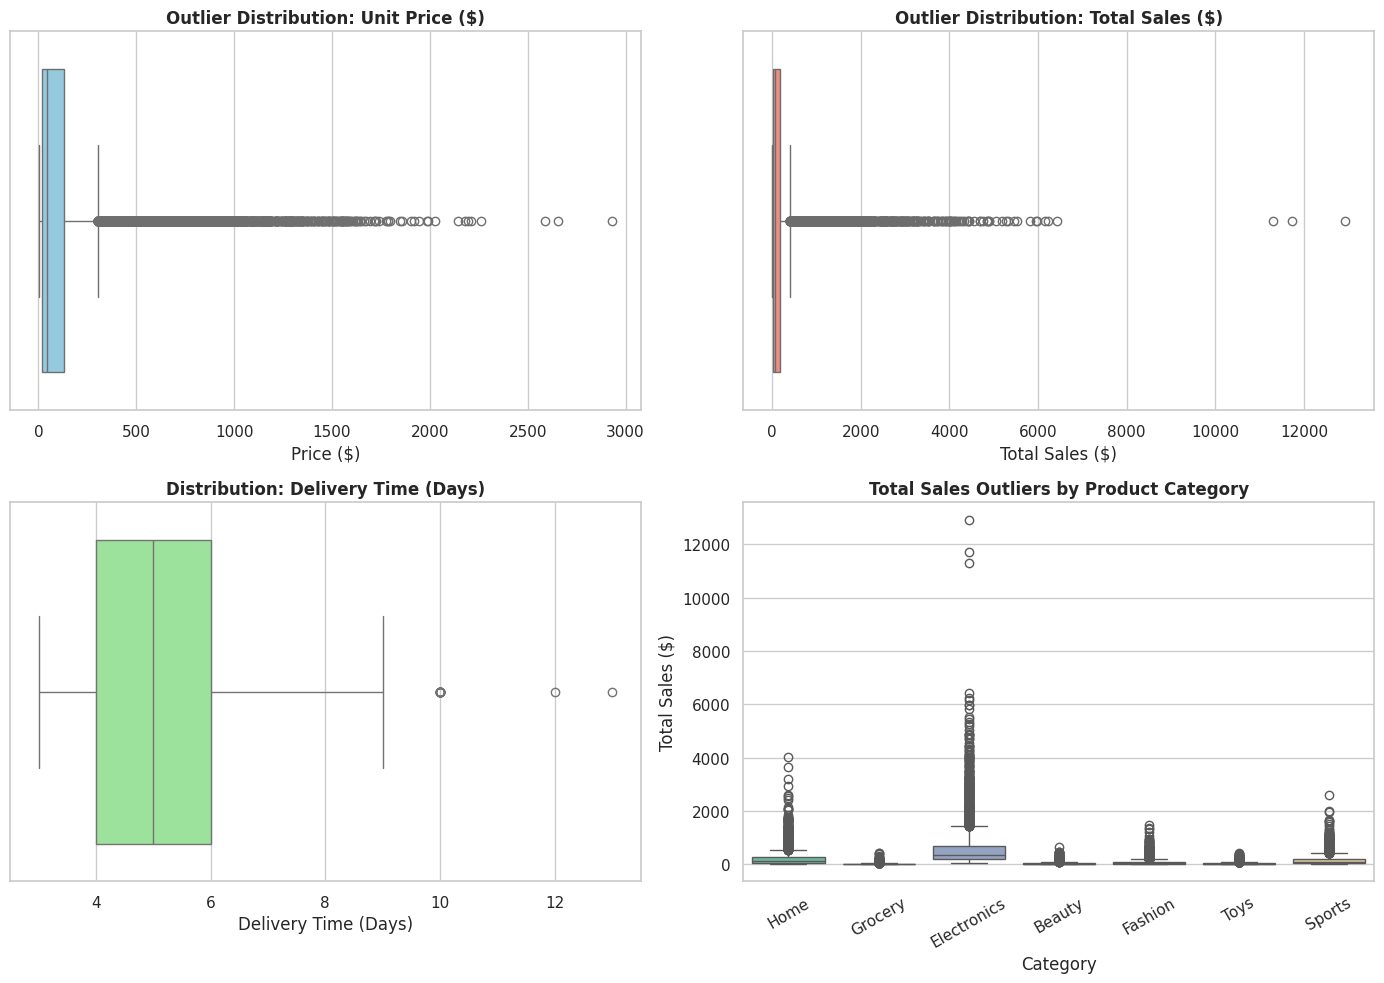

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='price', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Outlier Distribution: Unit Price ($)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price ($)')

sns.boxplot(data=df, x='total_sales', ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Outlier Distribution: Total Sales ($)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Total Sales ($)')

sns.boxplot(data=df, x='delivery_time_days', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution: Delivery Time (Days)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Delivery Time (Days)')

sns.boxplot(data=df, x='category', y='total_sales', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Total Sales Outliers by Product Category', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Total Sales ($)')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
cat_features = ['category', 'payment_method', 'region', 'returned']
cat_summary = []

for col in cat_features:
    if col in df.columns:
        top_cat = df[col].mode()[0]
        top_freq = df[col].value_counts().iloc[0]
        top_pct = (top_freq / len(df)) * 100

        cat_summary.append({
            'Feature': col,
            'Unique Categories': df[col].nunique(),
            'Top Category': top_cat,
            'Top Category Freq': top_freq,
            'Top Category %': round(top_pct, 2)
        })

cat_df = pd.DataFrame(cat_summary)
display(cat_df)

,Feature,Unique Categories,Top Category,Top Category Freq,Top Category %
0,category,7,Fashion,6254,18.13
1,payment_method,6,Credit Card,12170,35.28
2,region,5,South,7584,21.98
3,returned,2,No,32597,94.48


In [ ]:
for col in ['category', 'payment_method', 'region']:
    if col in df.columns:
        print(f"\nDistribution for '{col}':")
        print(df[col].value_counts(normalize=True).map(lambda n: f"{n:.2%}"))


Distribution for 'category':
category
Fashion        18.13%
Electronics    17.91%
Home           15.90%
Toys           12.31%
Sports         12.09%
Beauty         11.89%
Grocery        11.76%
Name: proportion, dtype: object

Distribution for 'payment_method':
payment_method
Credit Card    35.28%
Debit Card     24.65%
Cod            12.06%
Upi            12.05%
Paypal          9.98%
Wallet          5.99%
Name: proportion, dtype: object

Distribution for 'region':
region
South      21.98%
North      21.95%
East       20.01%
West       19.73%
Central    16.32%
Name: proportion, dtype: object


PART 4

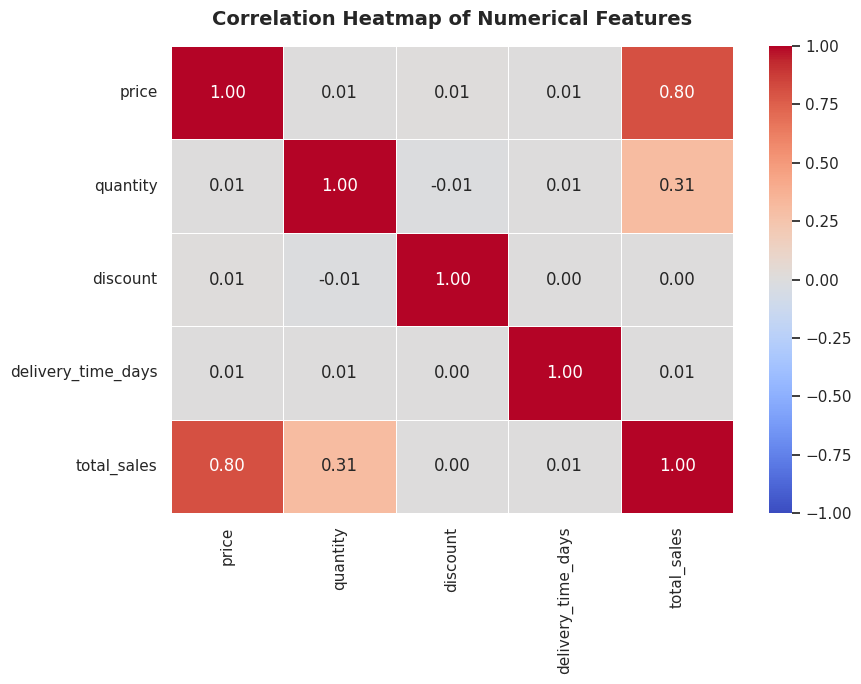

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['price', 'quantity', 'discount', 'delivery_time_days', 'total_sales']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

PART 5

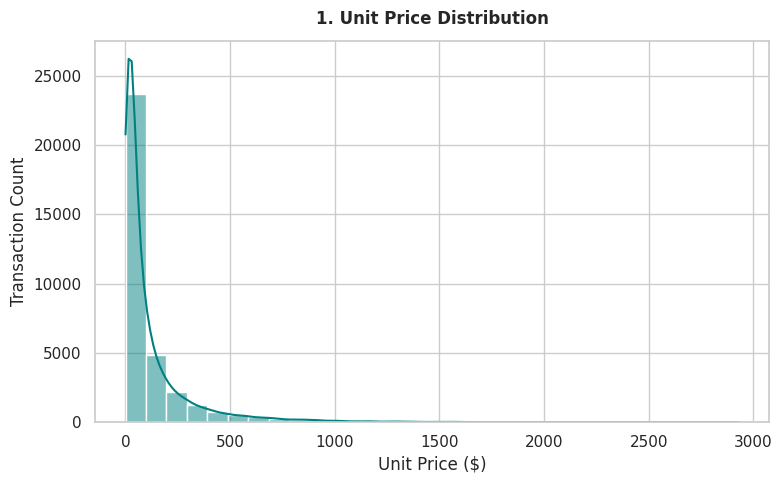

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

os.makedirs('images/visualizations', exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='teal', bins=30)
plt.title('1. Unit Price Distribution', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Unit Price ($)')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.savefig('images/visualizations/01_histogram_unit_price.png', dpi=300)
plt.show()

/tmp/ipykernel_2027/698804995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x='category', y='total_sales', palette='Blues_r')


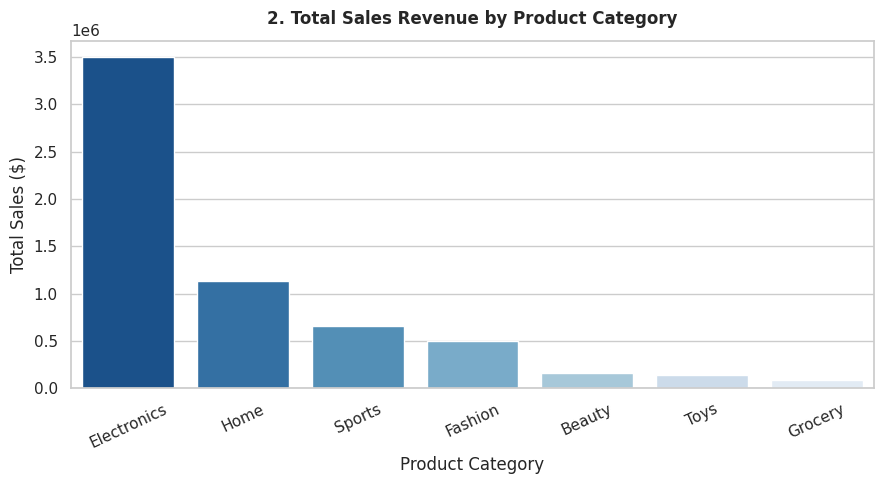

In [ ]:
plt.figure(figsize=(9, 5))
cat_sales = df.groupby('category')['total_sales'].sum().reset_index().sort_values(by='total_sales', ascending=False)
sns.barplot(data=cat_sales, x='category', y='total_sales', palette='Blues_r')
plt.title('2. Total Sales Revenue by Product Category', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig('images/visualizations/02_barchart_category_revenue.png', dpi=300)
plt.show()

/tmp/ipykernel_2027/845827434.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='payment_method', order=df['payment_method'].value_counts().index, palette='Set2')


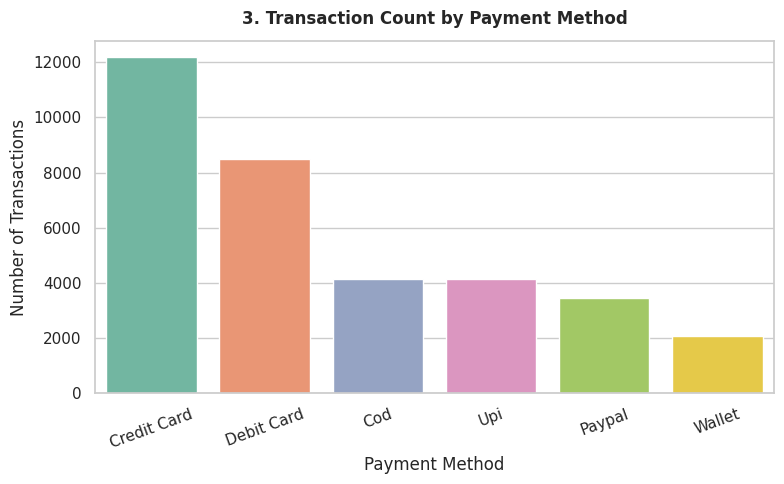

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='payment_method', order=df['payment_method'].value_counts().index, palette='Set2')
plt.title('3. Transaction Count by Payment Method', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('images/visualizations/03_countplot_payment_methods.png', dpi=300)
plt.show()

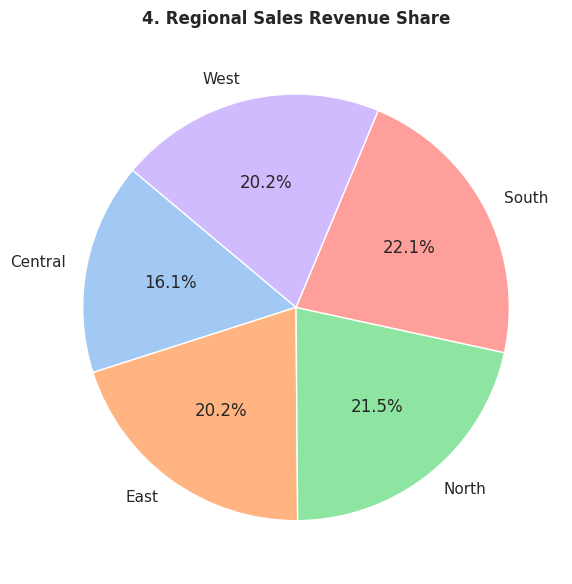

In [ ]:
plt.figure(figsize=(6, 6))
region_sales = df.groupby('region')['total_sales'].sum()
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('4. Regional Sales Revenue Share', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('images/visualizations/04_piechart_regional_share.png', dpi=300)
plt.show()

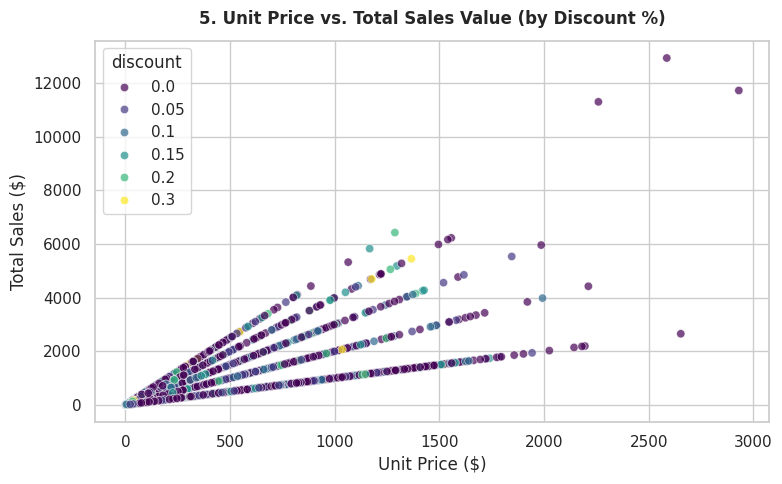

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='price', y='total_sales', hue='discount', palette='viridis', alpha=0.7)
plt.title('5. Unit Price vs. Total Sales Value (by Discount %)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Unit Price ($)')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('images/visualizations/05_scatterplot_price_vs_totalsales.png', dpi=300)
plt.show()

/tmp/ipykernel_2027/4078135164.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index('order_date').resample('M')['total_sales'].sum().reset_index()


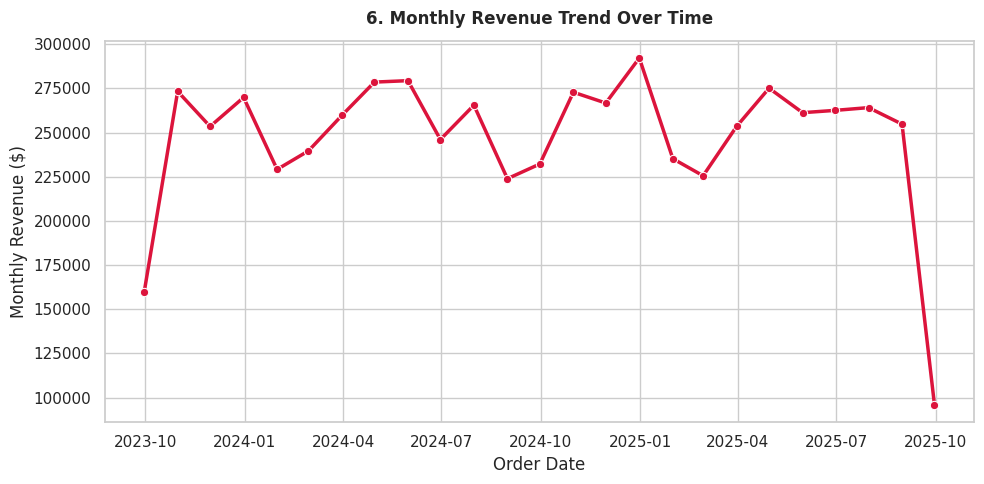

In [ ]:
plt.figure(figsize=(10, 5))
df_monthly = df.set_index('order_date').resample('M')['total_sales'].sum().reset_index()
sns.lineplot(data=df_monthly, x='order_date', y='total_sales', marker='o', color='crimson', linewidth=2.5)
plt.title('6. Monthly Revenue Trend Over Time', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Order Date')
plt.ylabel('Monthly Revenue ($)')
plt.tight_layout()
plt.savefig('images/visualizations/06_linechart_monthly_trend.png', dpi=300)
plt.show()

/tmp/ipykernel_2027/4147664726.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='total_sales', palette='Set3')


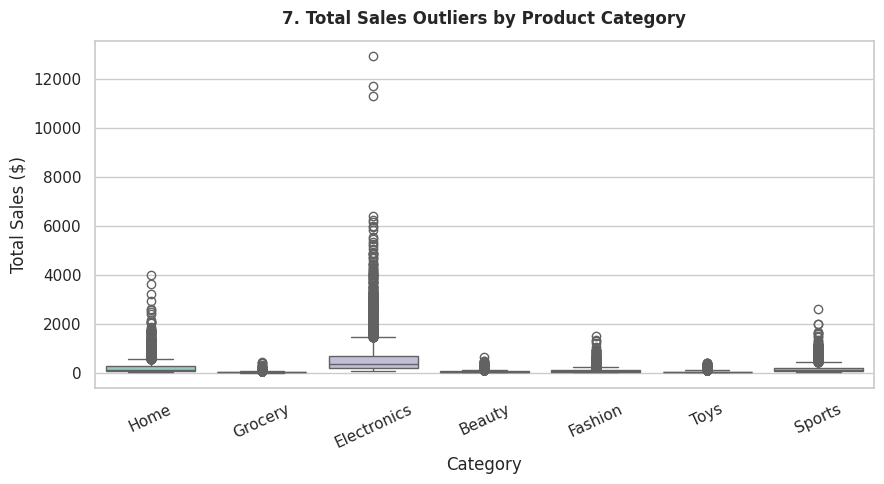

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='category', y='total_sales', palette='Set3')
plt.title('7. Total Sales Outliers by Product Category', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig('images/visualizations/07_boxplot_category_outliers.png', dpi=300)
plt.show()

/tmp/ipykernel_2027/1387268306.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=return_rates, x='category', y='return_pct', palette='Reds_r')


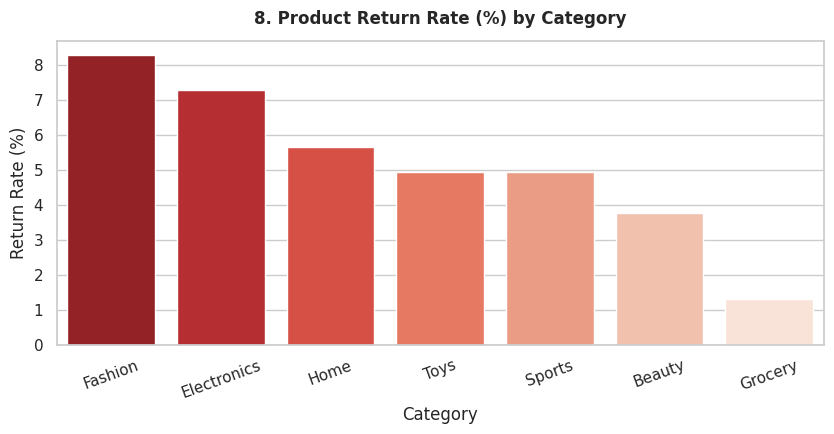

In [ ]:
plt.figure(figsize=(8.5, 4.5))
df['returned'] = df['returned'].map({'Yes': 1, 'No': 0})
return_rates = df.groupby('category')['returned'].mean().reset_index()
return_rates['return_pct'] = return_rates['returned'] * 100
return_rates = return_rates.sort_values(by='return_pct', ascending=False)
sns.barplot(data=return_rates, x='category', y='return_pct', palette='Reds_r')
plt.title('8. Product Return Rate (%) by Category', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('images/visualizations/08_barchart_return_rate_category.png', dpi=300)
plt.show()

/tmp/ipykernel_2027/456489850.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='category', y='discount', palette='Pastel2', inner='quartile')


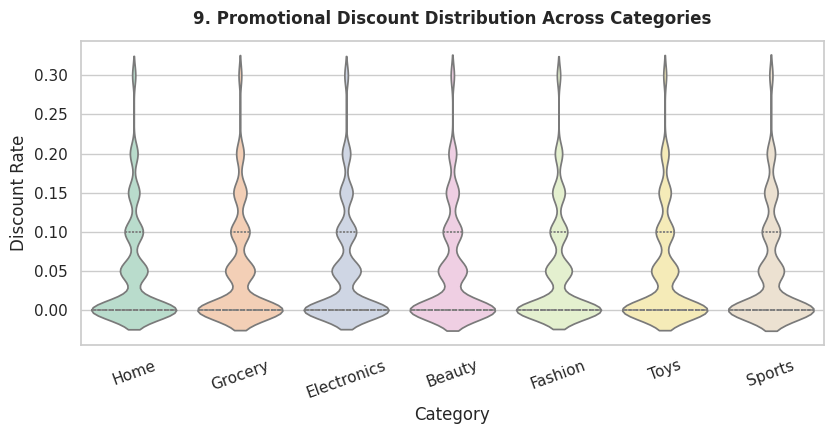

In [ ]:
plt.figure(figsize=(8.5, 4.5))
sns.violinplot(data=df, x='category', y='discount', palette='Pastel2', inner='quartile')
plt.title('9. Promotional Discount Distribution Across Categories', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Category')
plt.ylabel('Discount Rate')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('images/visualizations/09_violinplot_discount_category.png', dpi=300)
plt.show()

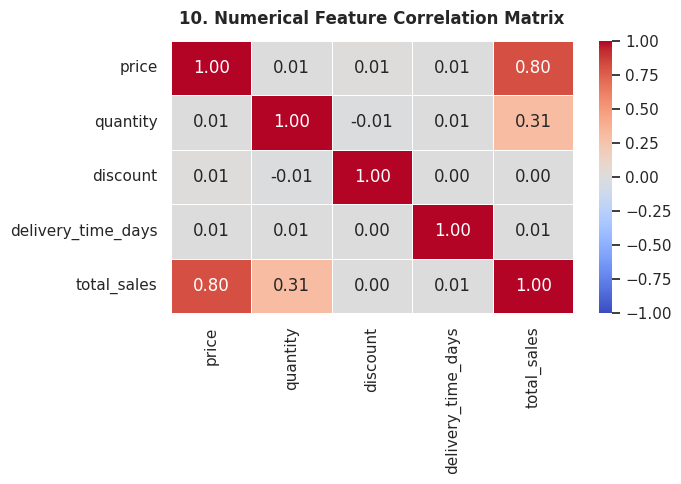

In [ ]:
plt.figure(figsize=(7, 5))
corr_matrix = df[['price', 'quantity', 'discount', 'delivery_time_days', 'total_sales']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('10. Numerical Feature Correlation Matrix', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('images/visualizations/10_heatmap_correlation.png', dpi=300)
plt.show()

/tmp/ipykernel_2027/923946976.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aov_region, x='region', y='total_sales', palette='PuBuGn_r')


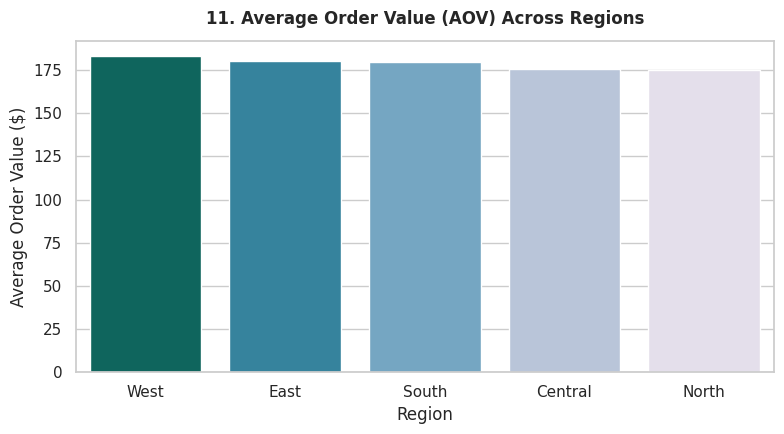

In [ ]:
plt.figure(figsize=(8, 4.5))
aov_region = df.groupby('region')['total_sales'].mean().reset_index().sort_values(by='total_sales', ascending=False)
sns.barplot(data=aov_region, x='region', y='total_sales', palette='PuBuGn_r')
plt.title('11. Average Order Value (AOV) Across Regions', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Region')
plt.ylabel('Average Order Value ($)')
plt.tight_layout()
plt.savefig('images/visualizations/11_barchart_aov_region.png', dpi=300)
plt.show()

/tmp/ipykernel_2027/2183899093.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_pivot = df.pivot_table(index='order_date', columns='category', values='total_sales', aggfunc='sum').resample('M').sum().fillna(0)


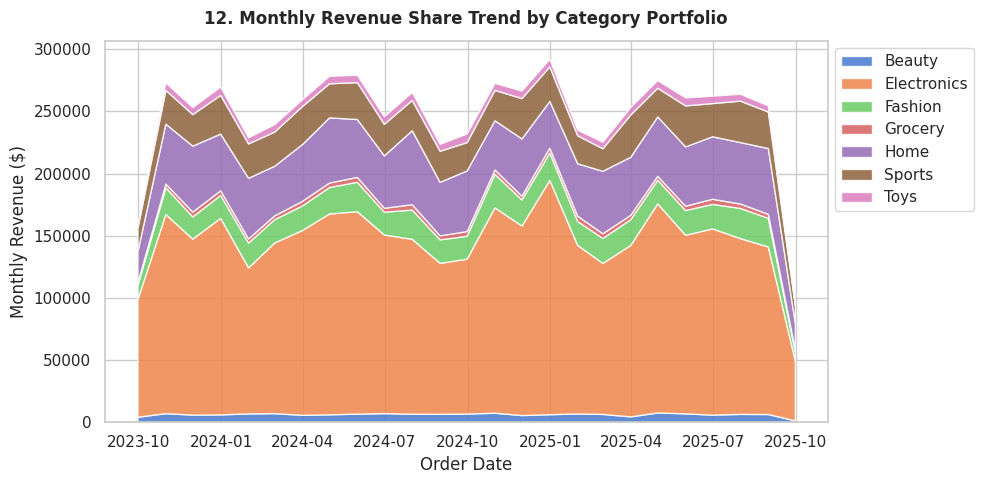

In [ ]:
plt.figure(figsize=(10, 5))
df_pivot = df.pivot_table(index='order_date', columns='category', values='total_sales', aggfunc='sum').resample('M').sum().fillna(0)
plt.stackplot(df_pivot.index, df_pivot.T, labels=df_pivot.columns, alpha=0.85)
plt.title('12. Monthly Revenue Share Trend by Category Portfolio', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Order Date')
plt.ylabel('Monthly Revenue ($)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('images/visualizations/12_stacked_area_category_trend.png', dpi=300)
plt.show()

/tmp/ipykernel_2027/3972603749.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='category', y='total_amount', hue='age_group', palette='Blues', ci=None)


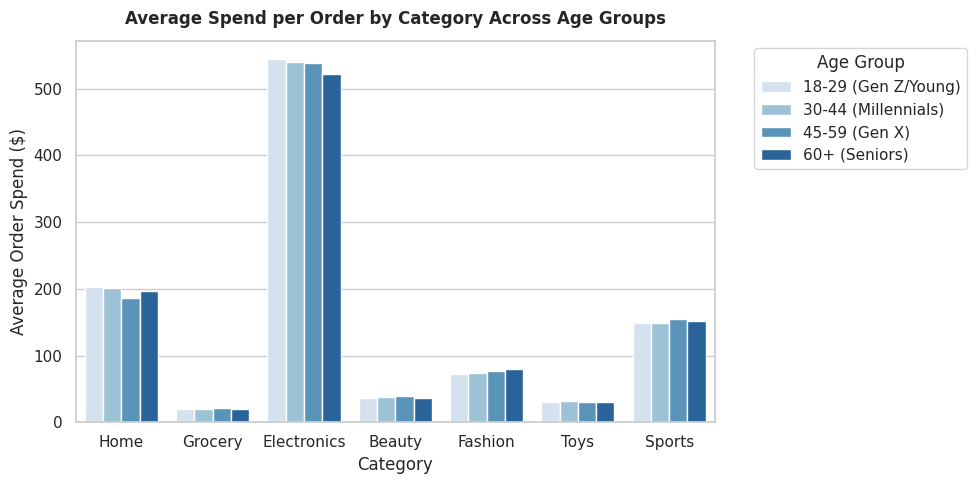

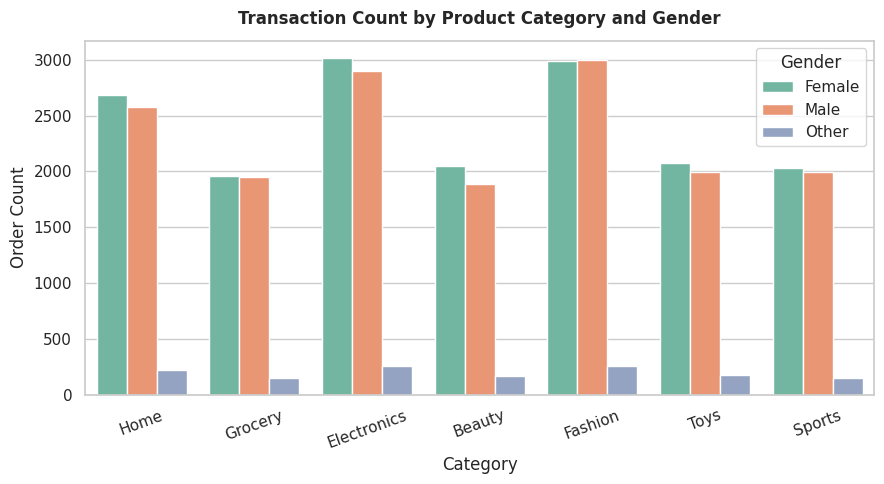

/tmp/ipykernel_2027/3972603749.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_returns, x='customer_gender', y='return_pct', palette='Pastel1')


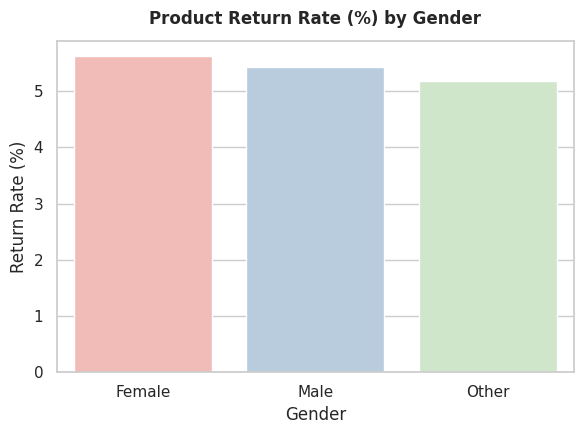

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[17, 29, 44, 59, 100],
    labels=['18-29 (Gen Z/Young)', '30-44 (Millennials)', '45-59 (Gen X)', '60+ (Seniors)']
)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='category', y='total_amount', hue='age_group', palette='Blues', ci=None)
plt.title('Average Spend per Order by Category Across Age Groups', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Category')
plt.ylabel('Average Order Spend ($)')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/visualizations/13_barchart_age_category_spend.png', dpi=300)
plt.show()

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='category', hue='customer_gender', palette='Set2')
plt.title('Transaction Count by Product Category and Gender', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Category')
plt.ylabel('Order Count')
plt.xticks(rotation=20)
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('images/visualizations/14_countplot_gender_category.png', dpi=300)
plt.show()

plt.figure(figsize=(6, 4.5))
gender_returns = df.groupby('customer_gender')['returned'].mean().reset_index()
gender_returns['return_pct'] = gender_returns['returned'] * 100
sns.barplot(data=gender_returns, x='customer_gender', y='return_pct', palette='Pastel1')
plt.title('Product Return Rate (%) by Gender', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Gender')
plt.ylabel('Return Rate (%)')
plt.tight_layout()
plt.savefig('images/visualizations/15_barchart_gender_returns.png', dpi=300)
plt.show()